# Exercícios — Clustering

**Tema:** Aprendizado Não Supervisionado › Clustering

Resolva antes de olhar o gabarito. **Dificuldade:** 🟢 base · 🟡 aplicação ·
🔴 síntese

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN, HDBSCAN
from sklearn.metrics import (silhouette_score, calinski_harabasz_score,
                             davies_bouldin_score, adjusted_rand_score)
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

rng = np.random.default_rng(505)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
CORES = np.array([AZUL, VERMELHO, VERDE, ROXO, AMBAR, "#5A5A5A", "#2A9D8F", "#E76F51"])
print("ambiente pronto")

ambiente pronto


---
## Dataset de trabalho: assinantes de um serviço de streaming

3.000 assinantes com seis features de uso. Existe uma coluna `cancelou`
(cancelou a assinatura no trimestre seguinte) que **não** deve entrar no
agrupamento — ela serve para validar. Há também a localização aproximada
de cada assinante (`x_km`, `y_km`), usada no exercício 4.

In [2]:
n = 3000
perfis = {  # prop, horas/sem, % séries, % infantil, dias ativos/mês, nº perfis, gasto extra, cancela
    "maratonistas": (0.30, 25, 0.80, 0.05, 26, 1.4, 5, 0.08),
    "família":      (0.25, 18, 0.30, 0.55, 22, 3.8, 12, 0.05),
    "cinéfilos":    (0.20, 8, 0.15, 0.05, 12, 1.3, 60, 0.15),
    "ocasionais":   (0.25, 2.5, 0.50, 0.10, 4, 1.5, 3, 0.35),
}
nomes_perfis = list(perfis)
perfil_oculto = rng.choice(4, n, p=[p[0] for p in perfis.values()])
P = np.array([p[1:] for p in perfis.values()])[perfil_oculto]
streaming = pd.DataFrame({
    "horas_semana": rng.lognormal(np.log(P[:, 0]), 0.35).round(1),
    "pct_series": rng.beta(P[:, 1] * 10, (1 - P[:, 1]) * 10).round(3),
    "pct_infantil": rng.beta(P[:, 2] * 10, (1 - P[:, 2]) * 10).round(3),
    "dias_ativos_mes": rng.binomial(30, P[:, 3] / 30),
    "n_perfis": (rng.poisson(P[:, 4] - 1) + 1).clip(1, 5),
    "gasto_extra_mensal": rng.lognormal(np.log(P[:, 5]), 0.5).round(2) * 10,  # em reais
})
cancelou = (rng.random(n) < P[:, 6]).astype(int)

# localização: três cidades de formatos diferentes + assinantes rurais espalhados
cidade_litoral = np.column_stack([np.cos(t := rng.uniform(0, np.pi, 1100)) * 30,
                                  np.sin(t) * 12]) + rng.normal(0, 1.4, (1100, 2))
cidade_redonda = rng.normal([60, 40], 4.0, (900, 2))
cidade_rodovia = np.column_stack([rng.uniform(-40, 10, 700), rng.uniform(-40, 10, 700) * 0.1 + 45]) \
    + rng.normal(0, 1.2, (700, 2))
rural = rng.uniform([-50, -20], [90, 70], (300, 2))
geo = np.vstack([cidade_litoral, cidade_redonda, cidade_rodovia, rural])
geo_verdade = np.repeat([0, 1, 2, -1], [1100, 900, 700, 300])
ordem = rng.permutation(n)
geo, geo_verdade = geo[ordem], geo_verdade[ordem]
streaming["x_km"], streaming["y_km"] = geo[:, 0].round(2), geo[:, 1].round(2)

colunas_uso = ["horas_semana", "pct_series", "pct_infantil", "dias_ativos_mes",
               "n_perfis", "gasto_extra_mensal"]
print(streaming.head().to_string())
print(f"\ntaxa de cancelamento: {cancelou.mean():.1%}")

   horas_semana  pct_series  pct_infantil  dias_ativos_mes  n_perfis  gasto_extra_mensal   x_km   y_km
0           2.1       0.516         0.388                4         2                22.2  39.56  32.99
1          13.8       0.335         0.044               12         1               724.0  62.95  40.36
2          28.8       0.901         0.032               25         1                59.7 -30.98  43.63
3           3.6       0.432         0.097                2         1                45.1  13.50   7.21
4           4.1       0.617         0.136                7         1                24.5  63.56  37.47

taxa de cancelamento: 15.1%


---
## Exercício 1 🟢 — Lloyd na mão

Pontos $x = [2, 3, 5, 10, 11, 14]$, $k = 2$, centróides iniciais 2 e 5.
Faça as iterações do algoritmo de Lloyd à mão (ou com NumPy puro, sem
`KMeans`), anotando os grupos, os centróides e a inércia a cada iteração,
até convergir. Depois confira com `KMeans(init=..., n_init=1)`.

In [3]:
# --- sua resposta ---

### Gabarito 1

In [4]:
x = np.array([2, 3, 5, 10, 11, 14], dtype=float)
c = np.array([2.0, 5.0])
for it in range(1, 10):
    grupos = np.abs(x[:, None] - c[None, :]).argmin(axis=1)
    novos = np.array([x[grupos == j].mean() for j in range(2)])
    inercia = ((x - novos[grupos]) ** 2).sum()
    print(f"iteração {it}: grupos={grupos}, centróides={novos.round(3)}, inércia={inercia:.3f}")
    if np.allclose(novos, c):
        break
    c = novos

km = KMeans(n_clusters=2, init=np.array([[2.0], [5.0]]), n_init=1).fit(x.reshape(-1, 1))
print(f"\nsklearn: centróides={km.cluster_centers_.ravel().round(3)}, inércia={km.inertia_:.3f}")

iteração 1: grupos=[0 0 1 1 1 1], centróides=[ 2.5 10. ], inércia=42.500
iteração 2: grupos=[0 0 0 1 1 1], centróides=[ 3.333 11.667], inércia=13.333
iteração 3: grupos=[0 0 0 1 1 1], centróides=[ 3.333 11.667], inércia=13.333

sklearn: centróides=[ 3.333 11.667], inércia=13.333


**Por quê:** na primeira atribuição, 10, 11 e 14 vão para o centróide 5
(o mais próximo), que então salta para a média $(5+10+11+14)/4 = 10$. Na
segunda atribuição o ponto 5 fica mais perto do centróide 2,5 do que do 10
e muda de grupo; os centróides vão para $10/3 \approx 3{,}33$ e
$35/3 \approx 11{,}67$. Na terceira, nada muda. A inércia cai de 42,5 para
13,33 — nunca sobe, como o `teoria.pdf` demonstra.

---
## Exercício 2 🟢 — Quem manda na distância?

Rode `KMeans(n_clusters=4)` nas `colunas_uso` **sem** padronizar e **com**
`StandardScaler`. Para cada caso, calcule o ARI contra `perfil_oculto` e
descubra qual coluna domina o agrupamento sem padronização (dica: compare
a variância de cada coluna, ou a diferença entre os centróides).

In [5]:
# --- sua resposta ---

### Gabarito 2

In [6]:
X_uso = streaming[colunas_uso].to_numpy()
rot_bruto = KMeans(4, n_init=10, random_state=0).fit_predict(X_uso)
Z_uso = StandardScaler().fit_transform(X_uso)
rot_pad = KMeans(4, n_init=10, random_state=0).fit_predict(Z_uso)
print(f"ARI sem padronizar: {adjusted_rand_score(perfil_oculto, rot_bruto):.3f}")
print(f"ARI padronizado   : {adjusted_rand_score(perfil_oculto, rot_pad):.3f}")

participacao = streaming[colunas_uso].var() / streaming[colunas_uso].var().sum()
print("\nparticipação de cada coluna na variância total (escala original):")
print((participacao * 100).round(2).astype(str).add("%").to_string())

ARI sem padronizar: 0.206
ARI padronizado   : 0.977

participação de cada coluna na variância total (escala original):
horas_semana           0.15%
pct_series              0.0%
pct_infantil            0.0%
dias_ativos_mes        0.09%
n_perfis                0.0%
gasto_extra_mensal    99.76%


**Por quê:** `gasto_extra_mensal` está em reais e tem variância ordens de
grandeza maior que as proporções (`pct_series`, entre 0 e 1). Na distância
euclidiana ao quadrado, ela responde por quase toda a soma — o k-means sem
padronização agrupa assinantes praticamente só pelo gasto extra.
Padronizar dá a cada coluna o mesmo peso, e os perfis de uso reaparecem.

---
## Exercício 3 🟡 — Escolhendo k com quatro critérios

Nos dados de uso padronizados, calcule para $k = 2, \dots, 7$: silhueta,
Calinski-Harabasz, Davies-Bouldin e a estabilidade por bootstrap (ARI
médio entre a partição original e 10 reamostras). Qual $k$ você escolheria
e por quê?

In [7]:
# --- sua resposta ---

### Gabarito 3

In [8]:
def estabilidade(Z, k, n_boot=10):
    base = KMeans(k, n_init=10, random_state=0).fit(Z)
    aris = []
    for b in range(n_boot):
        idx = np.random.default_rng(b).choice(len(Z), len(Z), replace=True)
        aris.append(adjusted_rand_score(
            base.labels_, KMeans(k, n_init=5, random_state=b).fit(Z[idx]).predict(Z)))
    return np.mean(aris)

linhas = []
for k in range(2, 8):
    rot = KMeans(k, n_init=10, random_state=0).fit_predict(Z_uso)
    linhas.append({"k": k, "silhueta": silhouette_score(Z_uso, rot),
                   "CH": calinski_harabasz_score(Z_uso, rot),
                   "DB": davies_bouldin_score(Z_uso, rot),
                   "estabilidade": estabilidade(Z_uso, k)})
print(pd.DataFrame(linhas).set_index("k").round(3).to_string())

   silhueta        CH     DB  estabilidade
k                                         
2     0.368  1597.582  1.275         0.999
3     0.484  2336.643  0.857         1.000
4     0.522  2938.008  0.736         0.998
5     0.477  2610.019  0.970         0.931
6     0.457  2505.064  0.991         0.959
7     0.381  2402.501  1.101         0.951


**Por quê:** os critérios convergem para $k=4$ — silhueta e CH máximos, DB
mínimo, e a estabilidade continua alta. Para $k > 4$, o algoritmo precisa
cortar um perfil real ao meio, e o corte muda de reamostra para reamostra
(estabilidade cai). Quando os critérios concordam assim, a escolha é
tranquila; quando discordam, a estabilidade e a utilidade de negócio
desempatam.

---
## Exercício 4 🟡 — Onde moram os assinantes: DBSCAN vs. k-means

Use as coordenadas (`x_km`, `y_km`). Existem três cidades de formatos
diferentes (uma em arco, uma redonda, uma alongada ao longo de uma
rodovia) e assinantes rurais espalhados. (a) Faça o gráfico da
k-distância com $k=10$ e escolha `eps`. (b) Rode DBSCAN e k-means com
$k=3$ e compare, via ARI, contra `geo_verdade` (em que -1 é rural).
(c) Quantos assinantes o DBSCAN marca como ruído, e quantos deles são de
fato rurais?

In [9]:
# --- sua resposta ---

### Gabarito 4

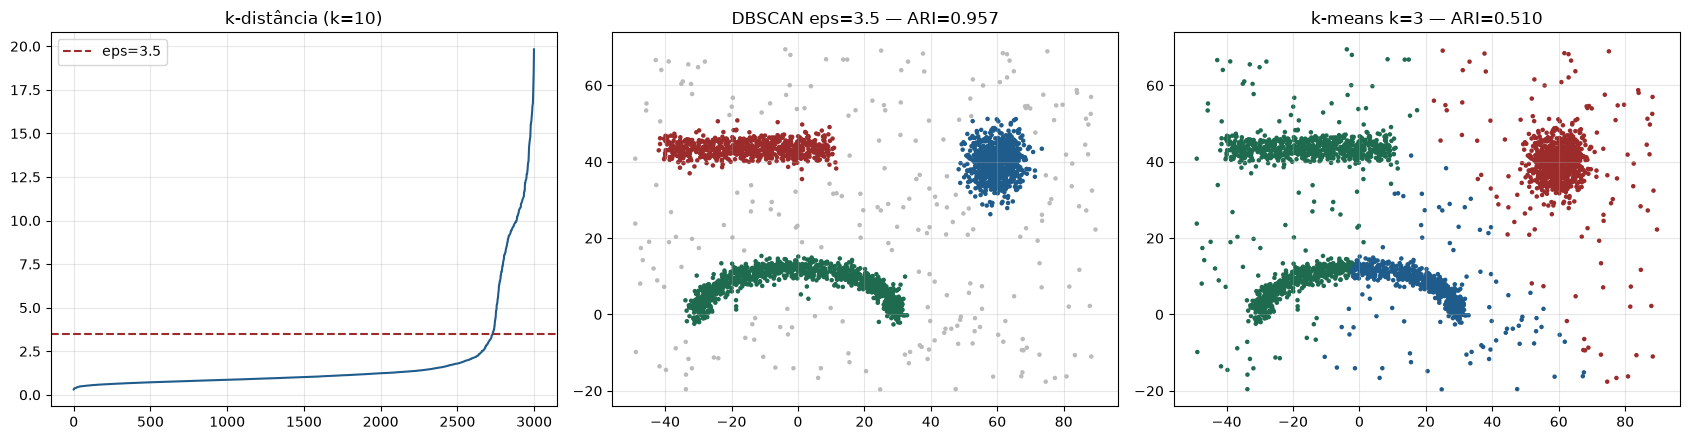

DBSCAN: 3 grupos, 239 pontos de ruído
desses, 99% são de fato rurais; e 79% dos rurais foram marcados como ruído


In [10]:
G = streaming[["x_km", "y_km"]].to_numpy()
dist10 = np.sort(NearestNeighbors(n_neighbors=10).fit(G).kneighbors(G)[0][:, -1])
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(17, 4.5))
ax1.plot(dist10, color=AZUL); ax1.axhline(3.5, color=VERMELHO, ls="--", label="eps=3.5")
ax1.set_title("k-distância (k=10)"); ax1.legend()

rot_db = DBSCAN(eps=3.5, min_samples=10).fit_predict(G)
rot_km = KMeans(3, n_init=10, random_state=0).fit_predict(G)
for ax, rot, tit in [(ax2, rot_db, "DBSCAN eps=3.5"), (ax3, rot_km, "k-means k=3")]:
    ax.scatter(G[:, 0], G[:, 1], s=5, c=np.where(rot >= 0, CORES[rot % 8], "#BBBBBB"))
    ax.set_title(f"{tit} — ARI={adjusted_rand_score(geo_verdade, rot):.3f}")
plt.tight_layout(); plt.show()

ruido = rot_db == -1
print(f"DBSCAN: {len(set(rot_db)) - 1} grupos, {ruido.sum()} pontos de ruído")
print(f"desses, {np.mean(geo_verdade[ruido] == -1):.0%} são de fato rurais; "
      f"e {np.mean(ruido[geo_verdade == -1]):.0%} dos rurais foram marcados como ruído")

**Por quê:** o joelho da k-distância fica perto de 3–4 km: dentro das
cidades o 10º vizinho está a poucos km; na zona rural, a dezenas. O
DBSCAN recupera o arco e a faixa da rodovia e marca a maior parte dos
rurais como ruído. O k-means, obrigado a colocar todo mundo em 3 grupos
convexos, corta o arco e distribui os rurais pelos grupos urbanos.
(Alguns rurais que caem por acaso dentro de uma cidade são absorvidos por
ela — o que é geograficamente correto.)

---
## Exercício 5 🔴 — GMM, BIC e o teste do desfecho

Nos dados de uso (as seis `colunas_uso`), aplique `np.log1p` em
`horas_semana` e `gasto_extra_mensal` e padronize.

(a) Escolha $K$ e o `covariance_type` pelo BIC ($K = 2, \dots, 7$, os quatro
tipos).
(b) Olhe as medianas de cada componente na escala original. O BIC escolheu
mais componentes do que perfis de assinante realmente distintos? Agrupe as
componentes em segmentos com nome de negócio.
(c) Explique por que o BIC fez isso (dica: olhe a coluna `n_perfis`).
(d) Mostre que a taxa de cancelamento difere entre os segmentos —
lembrando que `cancelou` não entrou no modelo.
(e) A probabilidade de um assinante pertencer a um **segmento** é a soma
das probabilidades das componentes daquele segmento. Quantos assinantes
ficam ambíguos (probabilidade do segmento mais provável abaixo de 0,7)?

In [11]:
# --- sua resposta ---

### Gabarito 5

In [12]:
uso = streaming[colunas_uso].copy()
for col in ["horas_semana", "gasto_extra_mensal"]:
    uso[col] = np.log1p(uso[col])
Zg = StandardScaler().fit_transform(uso)

bics = {(tipo, K): GaussianMixture(K, covariance_type=tipo, n_init=2, random_state=0)
        .fit(Zg).bic(Zg)
        for tipo in ["spherical", "diag", "tied", "full"] for K in range(2, 8)}
print(pd.Series(bics).unstack(0).round(0).to_string())
tipo, K = min(bics, key=bics.get)
print(f"\nmenor BIC: covariance_type='{tipo}', K={K}")

gmm = GaussianMixture(K, covariance_type=tipo, n_init=3, random_state=0).fit(Zg)
comp = gmm.predict(Zg)
medianas = streaming[colunas_uso].groupby(comp).median()
medianas["tamanho"] = np.bincount(comp)
print("\n" + medianas.round(2).to_string())

      diag     full  spherical     tied
2  40581.0  31321.0    47465.0  36181.0
3  32719.0  28633.0    36851.0  32281.0
4  26019.0  26428.0    29344.0  27645.0
5  20381.0  20897.0    28393.0  27026.0
6  20337.0  20932.0    28027.0  26913.0
7  13370.0  14089.0    27709.0  26915.0

menor BIC: covariance_type='diag', K=7

   horas_semana  pct_series  pct_infantil  dias_ativos_mes  n_perfis  gasto_extra_mensal  tamanho
0         17.00        0.28          0.56             22.0       5.0               120.0      377
1          2.60        0.51          0.07              4.0       2.0                32.1      268
2         25.40        0.82          0.02             26.0       1.0                50.1      595
3          7.80        0.12          0.03             12.0       1.0               613.8      613
4          2.50        0.49          0.08              4.0       1.0                31.1      481
5         25.80        0.81          0.02             26.0       2.0                50.5   

In [13]:
# (b) cada componente recebe o nome pelo seu perfil — várias podem ter o mesmo nome
def nome_do_perfil(linha):
    if linha["pct_infantil"] > 0.4:
        return "família"
    if linha["horas_semana"] < 5:
        return "ocasionais"
    if linha["gasto_extra_mensal"] > 300:
        return "cinéfilos"
    return "maratonistas"

nome_comp = medianas.apply(nome_do_perfil, axis=1)
print(pd.DataFrame({"segmento": nome_comp, "n_perfis (mediana)": medianas["n_perfis"],
                    "tamanho": medianas["tamanho"]}).to_string())

segmento = nome_comp.loc[comp].to_numpy()
print(f"\nARI componentes vs. perfis ocultos: {adjusted_rand_score(perfil_oculto, comp):.3f}")
print(f"ARI segmentos vs. perfis ocultos  : {adjusted_rand_score(perfil_oculto, segmento):.3f}")

       segmento  n_perfis (mediana)  tamanho
0       família                 5.0      377
1    ocasionais                 2.0      268
2  maratonistas                 1.0      595
3     cinéfilos                 1.0      613
4    ocasionais                 1.0      481
5  maratonistas                 2.0      300
6       família                 3.0      366

ARI componentes vs. perfis ocultos: 0.699
ARI segmentos vs. perfis ocultos  : 0.997


In [14]:
# (d) desfecho e (e) ambiguidade no nível do segmento
prob_comp = gmm.predict_proba(Zg)
prob_seg = pd.DataFrame(prob_comp).T.groupby(nome_comp.to_numpy()).sum().T
ambiguo = prob_seg.max(axis=1).to_numpy() < 0.7
resumo = pd.DataFrame({"segmento": segmento, "cancelou": cancelou, "ambiguo": ambiguo})
tab = resumo.groupby("segmento").agg(n=("cancelou", "size"), taxa_cancelamento=("cancelou", "mean"),
                                     pct_ambiguos=("ambiguo", "mean"))
print(tab.round(3).to_string())
print(f"\nassinantes ambíguos no total: {ambiguo.sum()} ({ambiguo.mean():.1%})")

                n  taxa_cancelamento  pct_ambiguos
segmento                                          
cinéfilos     613              0.134           0.0
família       743              0.050           0.0
maratonistas  895              0.078           0.0
ocasionais    749              0.352           0.0

assinantes ambíguos no total: 0 (0.0%)


**Como avaliar sua resposta:**

(a) O BIC escolhe o maior $K$ testado (7). (b) As medianas mostram por quê:
há dois componentes de "família", dois de "ocasionais" e dois de
"maratonistas", que diferem entre si quase só em `n_perfis`. Os sete
componentes são, na verdade, **quatro segmentos**; agrupados, eles
recuperam os perfis ocultos com ARI muito maior que o dos componentes
crus.

(c) O BIC mede quantas **gaussianas** são necessárias para descrever a
densidade dos dados — não quantos **segmentos** de negócio existem.
`n_perfis` é discreta, com poucos valores: cada perfil de assinante vira
uma pilha de pontos em "1 perfil", outra em "2 perfis", e o GMM ganha
verossimilhança modelando cada pilha com uma gaussiana própria. O mesmo
acontece com features limitadas e assimétricas (proporções perto de 0 ou
1). Moral: use o BIC como guia de densidade, e consolide componentes pelo
perfil antes de chamar cada uma de segmento.

(d) Ocasionais cancelam várias vezes mais que família e maratonistas, sem
que o cancelamento tenha entrado no modelo — é a validação por desfecho.
(e) Somando as probabilidades por segmento, quase ninguém fica ambíguo:
a incerteza que existia era entre componentes **do mesmo segmento** (1 ou 2
perfis na conta), que não muda a decisão de negócio.

---
## Fechamento

- Lloyd alterna atribuição e média; a inércia só desce, até um mínimo
  local.
- Sem padronização, a coluna de maior escala decide sozinha o
  agrupamento.
- Silhueta, CH, DB e estabilidade concordam quando a estrutura é clara; a
  estabilidade é o critério que não depende de premissa de forma.
- Formas não convexas e ruído pedem DBSCAN/HDBSCAN; k-means corta tudo em
  células convexas e não sabe dizer "não pertence a grupo nenhum".
- GMM dá probabilidades de pertinência e escolhe $K$ pelo BIC; a
  validação que convence o negócio é a do desfecho que ficou de fora.

→ Próximo módulo: **Redução de Dimensionalidade** — comprimir muitas
features em poucas, e visualizar dados de alta dimensão sem se enganar.